In [1]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import fbeta_score, make_scorer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import matplotlib.pyplot as plt
import seaborn as sns

import utils

sns.set_theme(style="whitegrid")
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

DATASET_PATH = "data/BRFSS2.csv"
TARGET = "Heart_Disease"

SEED = 42

In [2]:
# load dataset
X, y = utils.load_dataset(DATASET_PATH, TARGET)

# we use a hierarchical split
# 1. split the data in 80% train and 20% test
# 2. split the train again in 80% train and 20% val

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

# Data visualization

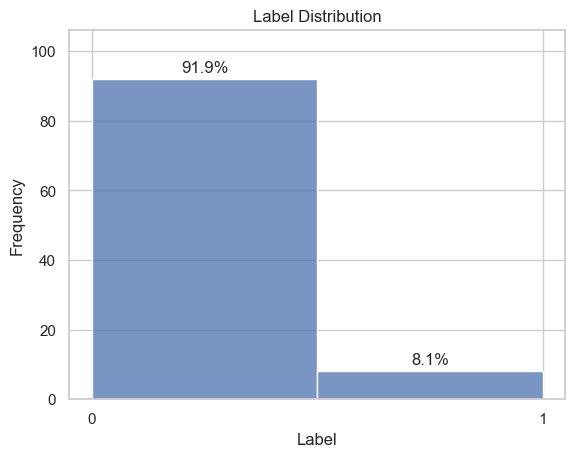

In [3]:
# first we want to visualize the data imbalance

ax = sns.histplot(y, bins=2, stat="percent")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Frequency")

plt.xticks([0, 1]) 
plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.show()

The dataset is strongly unbalanced, almost 92% of samples are negative sample, while only the 8% are positive
A model trained on this dataset will be strongly biased, as it needs to predict always the negative class to get 92% of the accuracy

We handle this imbalance later using either thresholding or advanced resampling algorihtm

Metric     | 
Accuracy   | 0.9189    
Precision  | 0.4884    
Recall     | 0.0578    
F1-Score   | 0.1034    
F2-Score   | 0.0702    
AUPRC      | 0.3059    



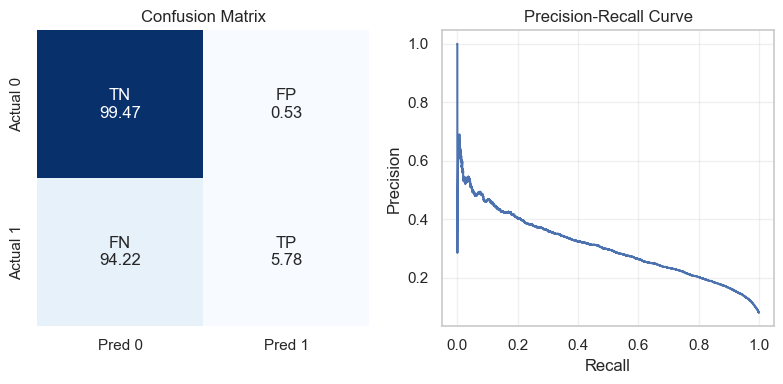

In [ ]:
# Testing a logistic regressor classifier
# because the logistic regressor is sensitive feature scales we need to normalize them first
# because all the features are >=0 we opt to use a minmax scaler to scale all the features in the range 0,1

logreg_clf = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(random_state=SEED, solver="saga"))
])

logreg_clf.fit(X_train, y_train)
y_val_probs = logreg_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

In [ ]:
# tuning the hyperparameters of the logistic regressor

param_grid = [
    {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2'],
        'clf__solver': ['saga']
    },
    {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l1'],
        'clf__solver': ['saga']
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=logreg_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'saga'}, F2: 0.0728


In [ ]:
# using the best hyperparameters we can investigate which class imbalance technique fit the best for the logistic regression
logreg_clf = ImbPipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("sampler", "passthrough"), 
    ("clf", LogisticRegression(C=10, penalty="l2", solver="saga", random_state=42))
])

param_grid = [
    {
        'sampler': [
            SMOTE(random_state=42), 
            SMOTEENN(random_state=42), 
            RandomUnderSampler(random_state=42)
        ],
        'clf__class_weight': [None], 
    },
    {
        'sampler': ['passthrough'], 
        'clf__class_weight': ['balanced'], 
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=logreg_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

/Users/mgiacobbe/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mgiacobbe/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mgiacobbe/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best hyperparameters: {'clf__class_weight': 'balanced', 'sampler': 'passthrough'}, F2: 0.5001


Metric     | 
Accuracy   | 0.7336    
Precision  | 0.2039    
Recall     | 0.7905    
F1-Score   | 0.3242    
F2-Score   | 0.5018    
AUPRC      | 0.3055    



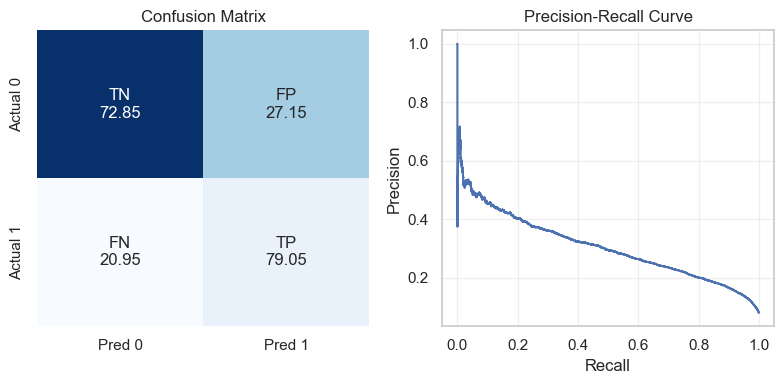

In [ ]:
# the performance of the optimized logistic regressor are
logreg_clf = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(C=10, penalty="l2", class_weight="balanced", random_state=SEED, solver="saga"))
])

logreg_clf.fit(X_train, y_train)
y_val_probs = logreg_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

Metric     | 
Accuracy   | 0.8609    
Precision  | 0.1967    
Recall     | 0.2338    
F1-Score   | 0.2136    
F2-Score   | 0.2253    
AUPRC      | 0.2462    



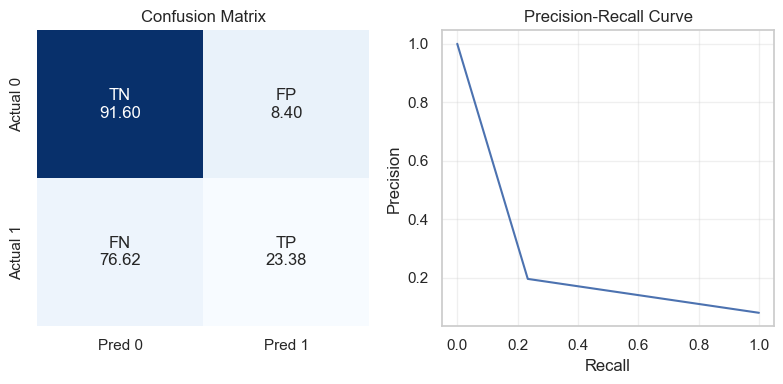

In [6]:
# Testing a decision tree classifier
# because three algorithm can handle different feature scales we don't apply the scaler here

dectree_clf = Pipeline(steps=[
    ('clf', DecisionTreeClassifier(random_state=SEED))
])

dectree_clf.fit(X_train, y_train)
y_val_probs = dectree_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

In [19]:
# tuning the hyperparameters of the decision tree classifier

param_grid = [
    {
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [5, 10, 15, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=dectree_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Best hyperparameters: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}, F2: 0.2240


In [ ]:
# using the best hyperparameters we can investigate which class imbalance technique fit the best for the decision tree
dectree_clf = ImbPipeline(steps=[
    ("sampler", "passthrough"), 
    ('clf', DecisionTreeClassifier(criterion="gini", min_samples_leaf=1, min_samples_split=2, random_state=SEED))
])

param_grid = [
    {
        'sampler': [
            SMOTE(random_state=SEED), 
            SMOTEENN(random_state=SEED), 
            RandomUnderSampler(random_state=SEED)
        ],
        'clf__class_weight': [None], 
    },
    {
        'sampler': ['passthrough'], 
        'clf__class_weight': ['balanced'], 
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=dectree_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Best hyperparameters: {'clf__class_weight': None, 'sampler': RandomUnderSampler(random_state=42)}, F2: 0.3865


Metric     | 
Accuracy   | 0.6675    
Precision  | 0.1505    
Recall     | 0.6703    
F1-Score   | 0.2458    
F2-Score   | 0.3965    
AUPRC      | 0.4238    



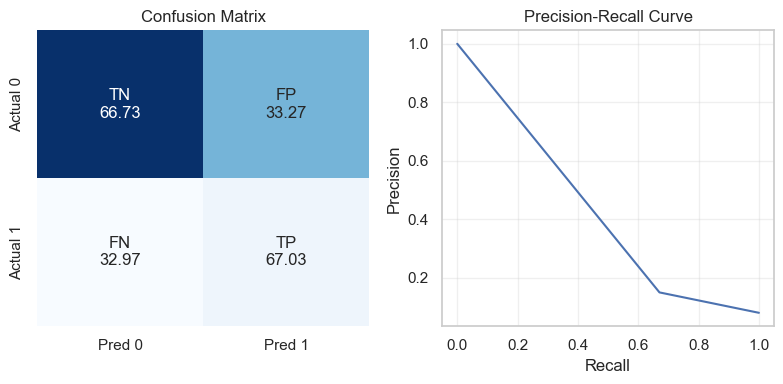

In [ ]:
# the performance of the optimized decision tree are
dectree_clf = Pipeline(steps=[
    ("sampler", RandomUnderSampler(random_state=42)),
    ('clf', DecisionTreeClassifier(criterion="gini", min_samples_leaf=1, min_samples_split=2, random_state=SEED))
])

dectree_clf.fit(X_train, y_train)
y_val_probs = dectree_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

Metric     | 
Accuracy   | 0.9183    
Precision  | 0.4447    
Recall     | 0.0423    
F1-Score   | 0.0773    
F2-Score   | 0.0517    
AUPRC      | 0.2688    



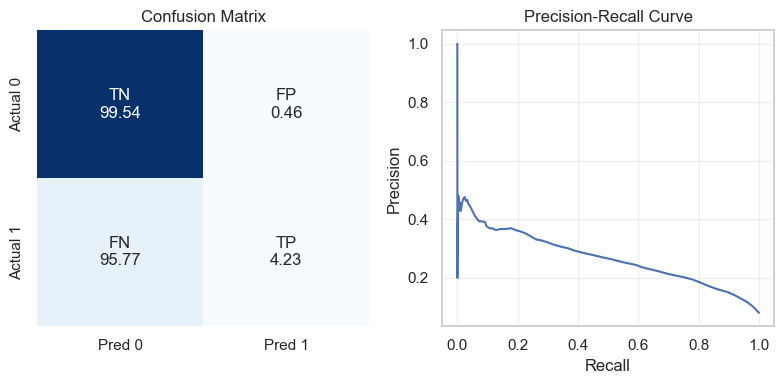

In [9]:
# Testing a random forest
# because three algorithm can handle different feature scales we don't apply the scaler here

ranfor_clf = Pipeline(steps=[
    ('clf', RandomForestClassifier(random_state=SEED))
])

ranfor_clf.fit(X_train, y_train)
y_val_probs = ranfor_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

In [10]:
# tuning the hyperparameters of the random forest

param_grid = [
    {
        'clf__n_estimators': [100, 200],
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [10, 20, None],
        'clf__max_features': ['sqrt'],
        'clf__class_weight': [None]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=ranfor_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Best hyperparameters: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}, F2: 0.0455


In [ ]:
# using the best hyperparameters we can investigate which class imbalance technique fit the best for the decision tree
ranfor_clf = ImbPipeline(steps=[
    ("sampler", "passthrough"), 
    ("clf", RandomForestClassifier(criterion="entropy", max_features="sqrt", random_state=SEED))
])

param_grid = [
    {
        'sampler': [
            SMOTE(random_state=SEED), 
            SMOTEENN(random_state=SEED), 
            RandomUnderSampler(random_state=SEED)
        ],
        'clf__class_weight': [None], 
    },
    {
        'sampler': ['passthrough'], 
        'clf__class_weight': ['balanced'], 
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=ranfor_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Best hyperparameters: {'clf__class_weight': None, 'sampler': RandomUnderSampler(random_state=42)}, F2: 0.4888


Metric     | 
Accuracy   | 0.7080    
Precision  | 0.1915    
Recall     | 0.8108    
F1-Score   | 0.3099    
F2-Score   | 0.4924    
AUPRC      | 0.2706    



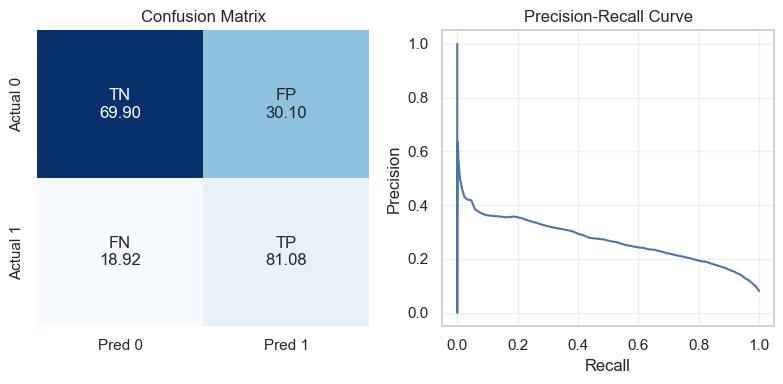

In [13]:
# the performance of the optimized random forest are
ranfor_clf = Pipeline(steps=[
    ("sampler", RandomUnderSampler(random_state=42)),
    ('clf', RandomForestClassifier(criterion="entropy", max_features="sqrt", random_state=SEED))
])

ranfor_clf.fit(X_train, y_train)
y_val_probs = ranfor_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

Metric     | 
Accuracy   | 0.9181    
Precision  | 0.4425    
Recall     | 0.0501    
F1-Score   | 0.0899    
F2-Score   | 0.0609    
AUPRC      | 0.2865    



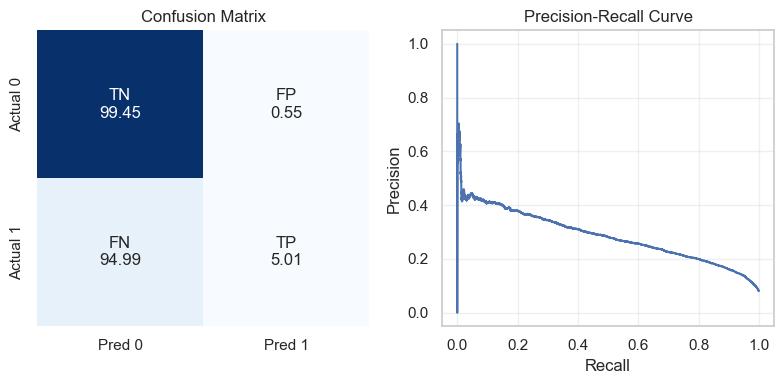

In [17]:
# Testing a XGBoost classifier
# because three algorithm can handle different feature scales we don't apply the scaler here

xgb_clf = Pipeline(steps=[
    ('clf', XGBClassifier(random_state=SEED))
])

xgb_clf.fit(X_train, y_train)
y_val_probs = xgb_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

In [21]:
# tuning the hyperparameters of the xgboost

param_grid = {
    'clf__learning_rate': [0.01, 0.1, 0.5],
    'clf__max_depth': [5, 7, 10, 15],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Best hyperparameters: {'clf__learning_rate': 0.5, 'clf__max_depth': 10}, F2: 0.1342


In [24]:
# using the best hyperparameters we can investigate which class imbalance technique fit the best for the decision tree
ranfor_clf = ImbPipeline(steps=[
    ("sampler", "passthrough"), 
    ("clf", XGBClassifier(learning_rate=0.5, max_depth=15, random_state=SEED)),
])

n_per_class = np.bincount(y_train.astype(int))
imb_ratio = n_per_class[0] / n_per_class[1]

param_grid = [
    {
        'sampler': [
            SMOTE(random_state=SEED), 
            SMOTEENN(random_state=SEED), 
            RandomUnderSampler(random_state=SEED)
        ],
        'clf__scale_pos_weight': [None], 
    },
    {
        'sampler': ['passthrough'], 
        'clf__scale_pos_weight': [1, imb_ratio], 
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=ranfor_clf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=f2_scorer, 
)

grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}, F2: {grid_search.best_score_:.4f}")

Rapporto di sbilanciamento calcolato: 11.37
Best hyperparameters: {'clf__scale_pos_weight': None, 'sampler': RandomUnderSampler(random_state=42)}, F2: 0.4598


Metric     | 
Accuracy   | 0.7054    
Precision  | 0.1834    
Recall     | 0.7655    
F1-Score   | 0.2959    
F2-Score   | 0.4682    
AUPRC      | 0.2413    



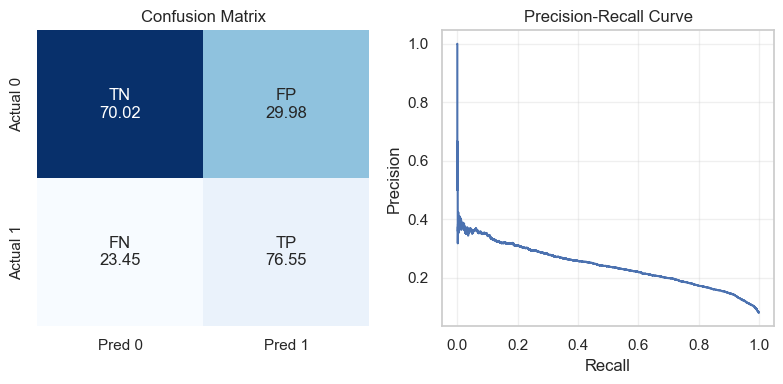

In [25]:
# the performance of the optimized random forest are
xgb_clf = Pipeline(steps=[
    ("sampler", RandomUnderSampler(random_state=SEED)),
    ("clf", XGBClassifier(learning_rate=0.5, max_depth=15, random_state=SEED)),
])

xgb_clf.fit(X_train, y_train)
y_val_probs = xgb_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

c:\Users\lucas\anaconda3\envs\speech\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== Logistic Regression ===
Metric     | 
Accuracy   | 0.7357    
Precision  | 0.2073    
Recall     | 0.8034    
F1-Score   | 0.3295    
F2-Score   | 0.5100    
AUPRC      | 0.3098    



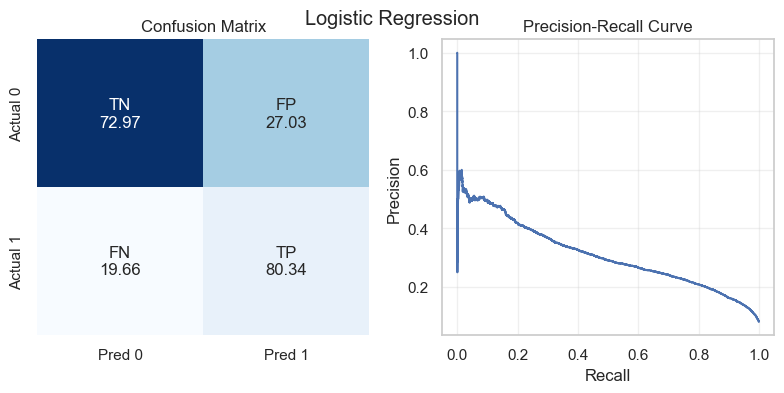

=== Decision Tree ===
Metric     | 
Accuracy   | 0.6651    
Precision  | 0.1483    
Recall     | 0.6622    
F1-Score   | 0.2423    
F2-Score   | 0.3911    
AUPRC      | 0.4189    



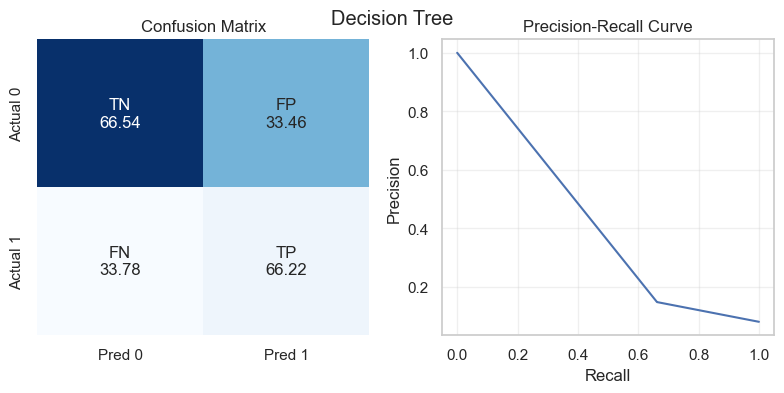

=== Random Forest ===
Metric     | 
Accuracy   | 0.7115    
Precision  | 0.1943    
Recall     | 0.8164    
F1-Score   | 0.3139    
F2-Score   | 0.4977    
AUPRC      | 0.2817    



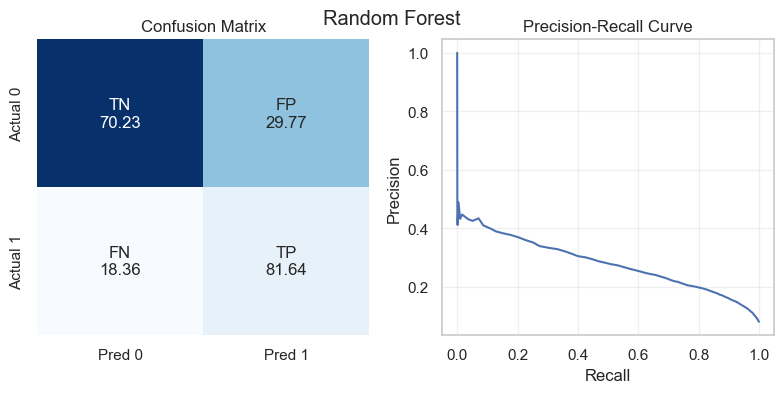

=== XGBoost ===
Metric     | 
Accuracy   | 0.7098    
Precision  | 0.1863    
Recall     | 0.7689    
F1-Score   | 0.2999    
F2-Score   | 0.4730    
AUPRC      | 0.2474    



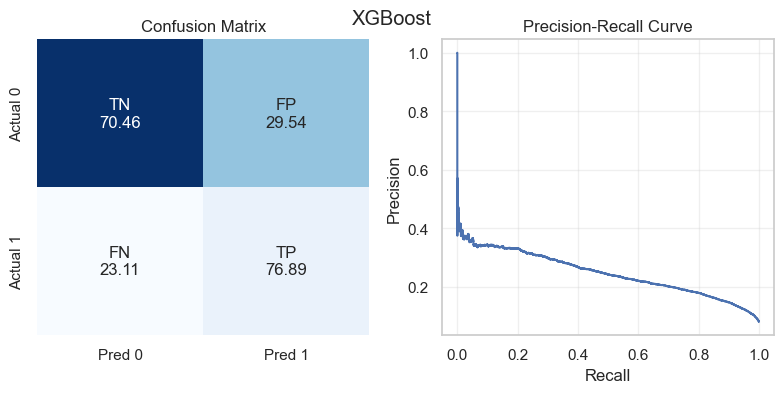

In [4]:
from imblearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("clf", LogisticRegression(C=10, penalty="l2", class_weight="balanced", random_state=SEED, solver="saga"))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("sampler", RandomUnderSampler(random_state=SEED)),
        ("clf", DecisionTreeClassifier(criterion="gini", min_samples_leaf=1, min_samples_split=2, random_state=SEED))
    ]),
    "Random Forest": Pipeline(steps=[
        ("sampler", RandomUnderSampler(random_state=SEED)),
        ("clf", RandomForestClassifier(criterion="entropy", max_features="sqrt", random_state=SEED))
    ]),
    "XGBoost": Pipeline(steps=[
        ("sampler", RandomUnderSampler(random_state=SEED)),
        ("clf", XGBClassifier(learning_rate=0.5, max_depth=15, random_state=SEED))
    ]),
}

# Train on train+val and evaluate on test
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

for name, model in models.items():
    model.fit(X_train_full, y_train_full)
    y_test_probs = model.predict_proba(X_test)[:, 1]
    metrics, fig, _ = utils.compute_metrics(y_test, y_test_probs)
    print(f"=== {name} ===")
    print(metrics)
    plt.figure(fig.number)
    plt.suptitle(name)
    plt.show()